# Οπτικοποίηση της Διάρκειας Παραμονής στο Τμήμα Επειγόντων Περιστατικών με PROC BOX

## Σύνοψη για Στελέχη

Μια ανάλυση νοσοκομειακών λειτουργιών που χρησιμοποιεί την PROC BOXPLOT (με ψευδώνυμο PROC BOX) για να συγκρίνει τη διάρκεια παραμονής στο τμήμα επειγόντων περιστατικών ανάμεσα σε τρεις κλινικές υπηρεσίες. Τα διπλανά σχηματικά θηκογράμματα δείχνουν με μία ματιά τη διάμεσο, τα τεταρτημόρια, τον μέσο όρο και τις ακραίες τιμές μεγάλης παραμονής κάθε υπηρεσίας.

Στις 100 προσομοιωμένες επισκέψεις, η διάμεση διάρκεια παραμονής αυξάνεται σταθερά από **40.0 ώρες στην Παθολογική** σε **50.4 ώρες στη Χειρουργική** και σε **60.5 ώρες στα Τραύματα**, ενώ οι μέσοι όροι ακολουθούν την ίδια σειρά (41.6, 54.6, 62.8 ώρες). Η Χειρουργική εμφανίζει τρεις υψηλές ακραίες τιμές πάνω από το άνω μουστάκι της (έως 84.3 ώρες) — τις περιπτώσεις αναμονής (boarding) που καταναλώνουν τις περισσότερες ώρες-κλίνης. Το notebook σχεδιάζει τη σύγκριση με τρεις τρόπους: ένα σχηματικό διάγραμμα, μια επικάλυψη τάσης μέσου όρου και μια οριζόντια διάταξη.

## Πηγές Δεδομένων

Όλα τα δεδομένα παράγονται εσωτερικά (inline) από το πρώτο βήμα DATA (`call streaminit(20260531)`)· δεν χρησιμοποιείται καμία εξωτερική ή δικτυακή είσοδος.

**`ed_los`** — μία γραμμή ανά επίσκεψη στο τμήμα επειγόντων περιστατικών (100 γραμμές)

| Μεταβλητή | Τύπος | Περιγραφή |
|----------|------|-------------|
| `PatientID` | Num | Διαδοχικός αναγνωριστικός αριθμός επίσκεψης (1-100) |
| `Department` | Char(12) | Υπηρεσία εισαγωγής: Medicine, Surgery, Trauma |
| `Severity` | Char(8) | Οξύτητα διαλογής: Routine (~55%), Urgent (~30%), Critical (~15%) |
| `LOS_Hours` | Num | Διάρκεια παραμονής σε ώρες· ένας μέσος όρος καθοδηγούμενος από την υπηρεσία και την οξύτητα συν κανονικός θόρυβος, με περιστασιακό σοκ μεγάλης παραμονής (με ετικέτα "Length of Stay (hours)") |

Η πραγματική κατανομή είναι Medicine 34 / Surgery 36 / Trauma 30 επισκέψεις, και Routine 51 / Urgent 35 / Critical 14 κατά οξύτητα διαλογής.

# Οπτικοποίηση της Διάρκειας Παραμονής στο Τμήμα Επειγόντων Περιστατικών με PROC BOX

Η διάρκεια παραμονής (LOS) είναι ένας από τους πιο στενά παρακολουθούμενους λειτουργικούς δείκτες σε ένα νοσοκομειακό τμήμα επειγόντων περιστατικών: καθορίζει τη διαθεσιμότητα κλινών, τη στελέχωση, τη ροή ασθενών και τους δείκτες ποιότητας. Οι μέσοι όροι από μόνοι τους κρύβουν την ιστορία — αυτό που έχει σημασία για μια ομάδα λειτουργιών είναι η *διασπορά* των παραμονών, οι *ακραίες τιμές* που δεσμεύουν πόρους, και το πώς διαφέρουν οι κατανομές ανάμεσα στις κλινικές υπηρεσίες.

Η PROC BOX (ψευδώνυμο της PROC BOXPLOT) είναι σχεδιασμένη ακριβώς για αυτή τη σύγκριση. Σχεδιάζει διπλανά θηκογράμματα (box-and-whisker), σημειώνοντας τη διάμεσο, τα τεταρτημόρια, τον μέσο όρο και τις ακραίες παρατηρήσεις κάθε ομάδας, ώστε ένας αναλυτής να διαβάζει με μία ματιά το σχήμα της κατανομής LOS κάθε υπηρεσίας.

Σε αυτό το notebook:

1. Παράγουμε ένα συνθετικό σύνολο δεδομένων επισκέψεων ΤΕΠ που ταιριάζει στο περιβάλλον των 100 παρατηρήσεων.
2. Παράγουμε ένα σχηματικό θηκόγραμμα της LOS ανά τμήμα, με τον συνοδευτικό πίνακα στατιστικών.
3. Επικαλύπτουμε μια γραμμή τάσης μέσου όρου με `BOXCONNECT=MEAN` για να καταστήσουμε σαφή τη διαβάθμιση των υπηρεσιών.
4. Επανασχεδιάζουμε την ίδια σύγκριση οριζόντια με `HORIZONTAL`.

## Βήμα 1 — Παραγωγή συνθετικών δεδομένων επισκέψεων ΤΕΠ

Προσομοιώνουμε 100 επισκέψεις στο τμήμα επειγόντων περιστατικών. Κάθε ασθενής αντιστοιχίζεται σε μία από τρεις κλινικές υπηρεσίες (Medicine, Surgery, Trauma) και σε μια οξύτητα διαλογής (Routine, Urgent, Critical). Η διάρκεια παραμονής χτίζεται από μια βασική τιμή ειδική για κάθε υπηρεσία, μετατοπισμένη προς τα πάνω για ασθενείς υψηλότερης οξύτητας, με κανονικά κατανεμημένο θόρυβο. Ένα μικρό ποσοστό επισκέψεων λαμβάνει ένα επιπλέον σοκ μεγάλης παραμονής ώστε να μιμηθεί τη βαριά δεξιά ουρά που εμφανίζουν πάντοτε τα πραγματικά δεδομένα ΤΕΠ (αναμονή, εισαγωγές που περιμένουν κλίνη νοσηλείας). Ο σταθερός σπόρος (seed) στην `call streaminit` καθιστά το σύνολο δεδομένων πλήρως αναπαραγώγιμο.

In [1]:
OPTIONS linesize=96;

ΔΕΔΟΜΕΝΑ ed_los;
   CALL streaminit(20260531);
   LENGTH Department $ 30 Severity $ 20;
   ΕΠΑΝΑΛΗΨΗ PatientID = 1 ΕΩΣ 100;
      d = rand('integer', 1, 3);
      ΕΑΝ d = 1 ΤΟΤΕ Department = "Παθολογική";
      ΑΛΛΙΩΣ ΕΑΝ d = 2 ΤΟΤΕ Department = "Χειρουργική";
      ΑΛΛΙΩΣ Department = "Τραύματα";

      u = rand('uniform');
      ΕΑΝ u < 0.55 ΤΟΤΕ s = 1;
      ΑΛΛΙΩΣ ΕΑΝ u < 0.85 ΤΟΤΕ s = 2;
      ΑΛΛΙΩΣ s = 3;
      ΕΑΝ s = 1 ΤΟΤΕ Severity = "Ρουτίνα";
      ΑΛΛΙΩΣ ΕΑΝ s = 2 ΤΟΤΕ Severity = "Επείγον";
      ΑΛΛΙΩΣ Severity = "Κρίσιμο";

      BASE = 24 + 10*d + 14*(s - 1);
      LOS_Hours = BASE + rand('normal', 0, 7);
      ΕΑΝ rand('uniform') < 0.06 ΤΟΤΕ
         LOS_Hours = LOS_Hours + rand('uniform', 40, 90);
      ΕΑΝ LOS_Hours < 2 ΤΟΤΕ LOS_Hours = 2;
      LOS_Hours = round(LOS_Hours, 0.1);
      ΕΞΟΔΟΣ;
   ΤΕΛΟΣ;
   ΑΦΑΙΡΕΣΗ d u s BASE;
   ΕΤΙΚΕΤΑ LOS_Hours  = "Διάρκεια Παραμονής (ώρες)"
         Department = "Τμήμα"
         Severity   = "Οξύτητα";
ΕΚΤΕΛΕΣΗ;


NOTE: Option LINESIZE changed to 96.
NOTE: DATA ed_los


NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## Βήμα 2 — Ταξινόμηση κατά τη μεταβλητή ομαδοποίησης

Η PROC BOX απαιτεί η μεταβλητή ομαδοποίησης (του οριζόντιου άξονα) να είναι ταξινομημένη ώστε οι παρατηρήσεις κάθε ομάδας να βρίσκονται συνεχόμενες. Ταξινομούμε κατά `Department` πριν από τη σχεδίαση.

In [2]:
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=ed_los;
   ΚΑΤΑ Department;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC SORT data=ed_los

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from ed_los.
NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: PROC SORT statement used.


## Βήμα 3 — Σχηματικό θηκόγραμμα

Η κύρια ανάλυση. Η σύνταξη `PLOT analysis-var * group-var` ζητά ένα κουτί ανά τμήμα. Η `BOXSTYLE=SCHEMATIC` παράγει ένα κλασικό σχηματικό διάγραμμα Tukey: τα μουστάκια εκτείνονται έως τις πιο ακραίες παρατηρήσεις εντός 1.5 φοράς του ενδοτεταρτημοριακού εύρους, και οποιαδήποτε σημεία πέρα από αυτό σχεδιάζονται μεμονωμένα ως ακραίες τιμές — ιδανικό για τον εντοπισμό των περιπτώσεων μεγάλης παραμονής που πιέζουν τη χωρητικότητα.

Η `NOHLABEL` καταστέλλει την περιττή ετικέτα του οριζόντιου άξονα, καθώς τα ονόματα των τμημάτων είναι αυτονόητα. Παράλληλα με το διάγραμμα, η PROC BOXPLOT εκτυπώνει έναν πίνακα στατιστικών που δίνει για κάθε τμήμα το N, το ελάχιστο, τα τεταρτημόρια, τη διάμεσο, το μέγιστο, τον μέσο όρο και την τυπική απόκλιση.

                              Διάρκεια Παραμονής στο ΤΕΠ ανά Τμήμα                              

              Διάρκεια Παραμονής στο ΤΕΠ ανά Τμήμα

                                     The BOXPLOT Procedure

Schematic Plots for Διάρκεια Παραμονής (ώρες)

Τμήμα                 N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Παθολογική           34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Τραύματα             30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
Χειρουργική          36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Διάρκεια Παραμονής στο ΤΕΠ ανά Τμήμα.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


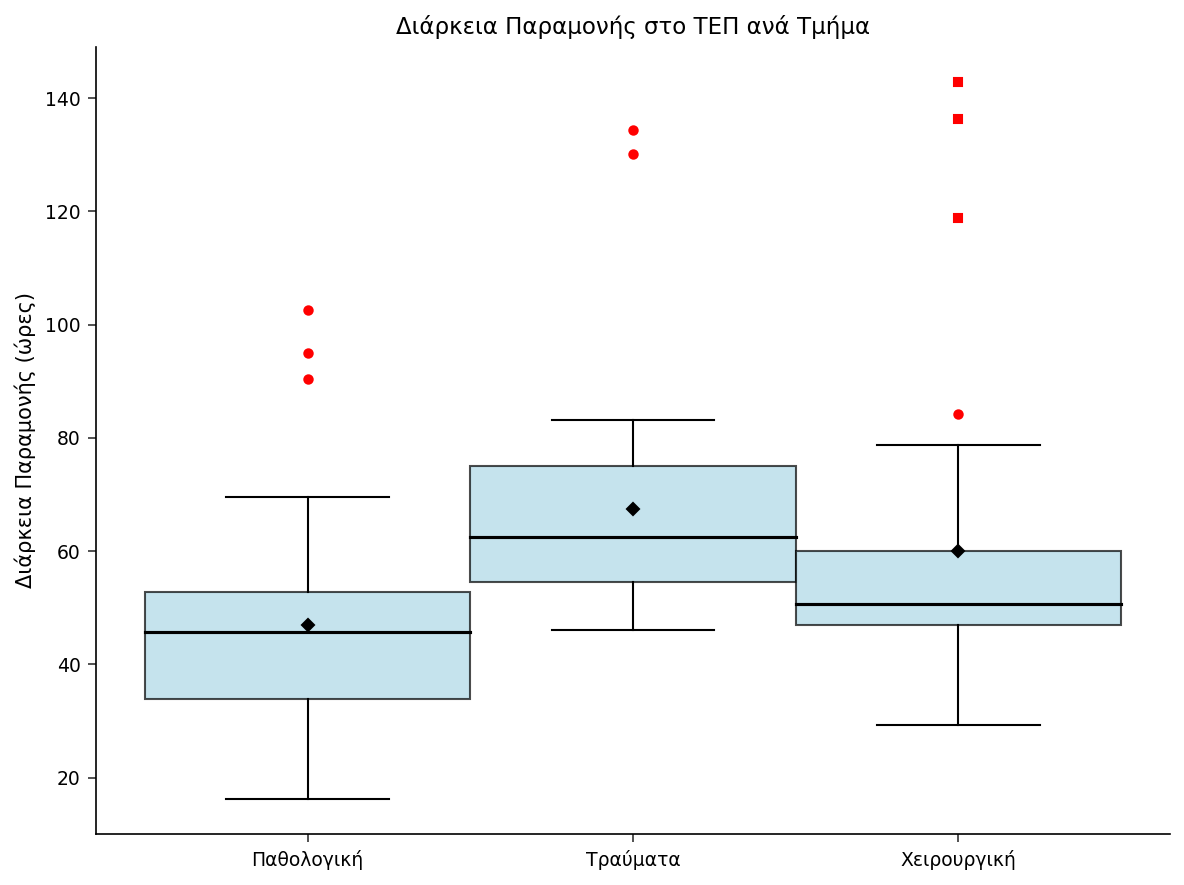

In [3]:
TITLE "Διάρκεια Παραμονής στο ΤΕΠ ανά Τμήμα";
ΔΙΑΔΙΚΑΣΙΑ boxplot ΔΕΔΟΜΕΝΑ=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle = schematic
      nohlabel;
ΕΚΤΕΛΕΣΗ;

## Βήμα 4 — Επικάλυψη μιας γραμμής τάσης μέσου όρου

Για να καταστήσουμε σαφή τη διαβάθμιση από υπηρεσία σε υπηρεσία, προσθέτουμε `BOXCONNECT=MEAN`. Η PROC BOXPLOT σχεδιάζει τότε μια γραμμή σύνδεσης που περνά από τον μέσο όρο κάθε κουτιού (τους δείκτες σε σχήμα ρόμβου), μετατρέποντας τις τρεις ξεχωριστές κατανομές σε μία ευανάγνωστη τάση. Επειδή τα τμήματα είναι διατεταγμένα Medicine → Surgery → Trauma, η ανοδική γραμμή σύνδεσης συνοψίζει την κλιμάκωση της μέσης διάρκειας παραμονής με μία μονοκοντυλιά — μια χρήσιμη ένδειξη για έναν πίνακα ελέγχου λειτουργιών.

                     Διάρκεια Παραμονής στο ΤΕΠ ανά Τμήμα — Τάση Μέσου Όρου                     

Διάρκεια Παραμονής στο ΤΕΠ ανά Τμήμα — Τάση Μέσου Όρου

                                     The BOXPLOT Procedure

Schematic Plots for Διάρκεια Παραμονής (ώρες)

Τμήμα                 N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Παθολογική           34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Τραύματα             30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
Χειρουργική          36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Διάρκεια Παραμονής στο ΤΕΠ ανά Τμήμα — Τάση Μέσου Όρου.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


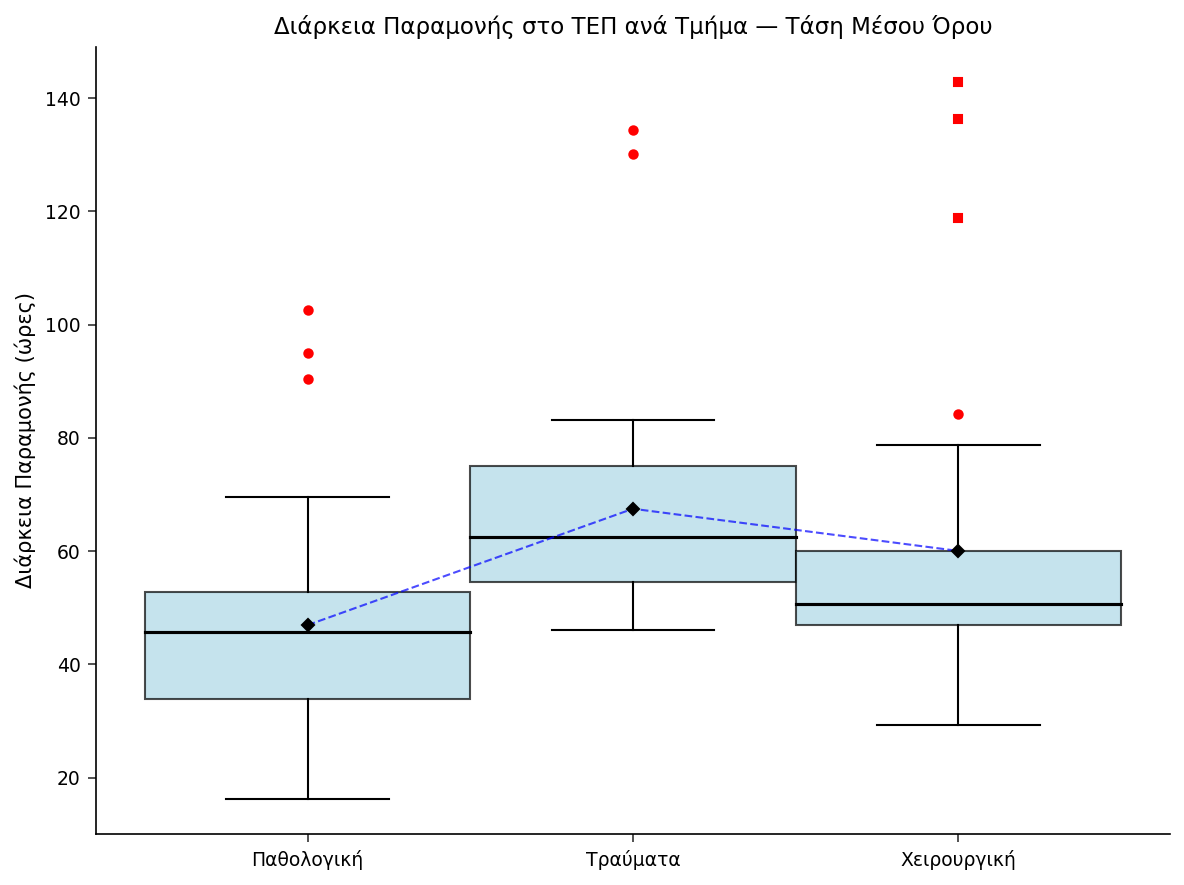

In [4]:
TITLE "Διάρκεια Παραμονής στο ΤΕΠ ανά Τμήμα — Τάση Μέσου Όρου";
ΔΙΑΔΙΚΑΣΙΑ boxplot ΔΕΔΟΜΕΝΑ=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle    = schematic
      boxconnect  = mean
      nohlabel;
ΕΚΤΕΛΕΣΗ;

## Βήμα 5 — Οριζόντια διάταξη

Η ίδια σύγκριση διαβάζεται φυσικά και στο πλάι της. Προσθέτοντας `HORIZONTAL` γίνεται εναλλαγή των αξόνων ώστε τα κουτιά να εκτείνονται από αριστερά προς τα δεξιά με την απόκριση στον άξονα x — μια διάταξη που κλιμακώνεται καλύτερα όταν τα ονόματα των υπηρεσιών είναι μεγάλα ή πολυάριθμα, και που προτιμούν πολλοί πίνακες ελέγχου λειτουργιών. Τα στατιστικά είναι πανομοιότυπα με την κατακόρυφη προβολή· αλλάζει μόνο ο προσανατολισμός.

                        Διάρκεια Παραμονής στο ΤΕΠ ανά Τμήμα — Οριζόντια                        

   Διάρκεια Παραμονής στο ΤΕΠ ανά Τμήμα — Οριζόντια

                                     The BOXPLOT Procedure

Schematic Plots for Διάρκεια Παραμονής (ώρες)

Τμήμα                 N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Παθολογική           34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Τραύματα             30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
Χειρουργική          36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Διάρκεια Παραμονής στο ΤΕΠ ανά Τμήμα — Οριζόντια.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


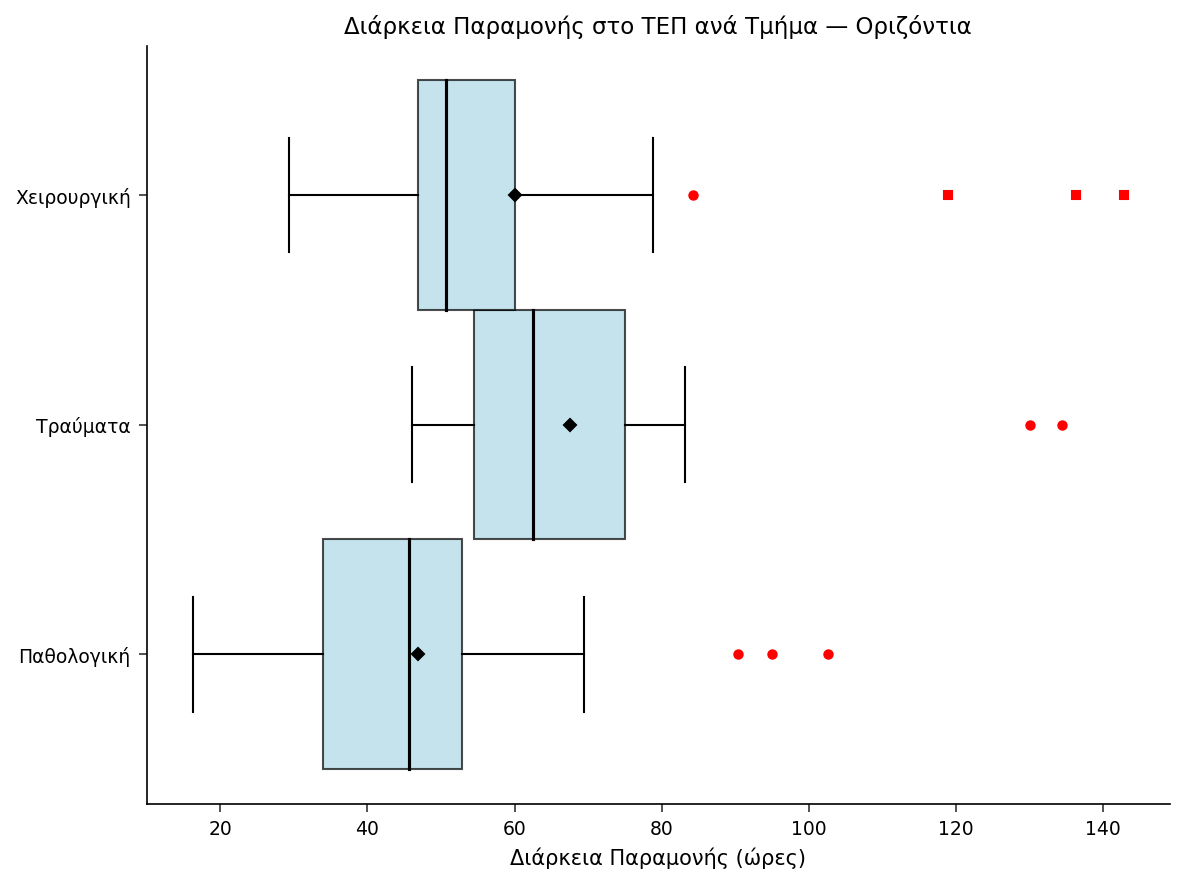

In [5]:
TITLE "Διάρκεια Παραμονής στο ΤΕΠ ανά Τμήμα — Οριζόντια";
ΔΙΑΔΙΚΑΣΙΑ boxplot ΔΕΔΟΜΕΝΑ=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle   = schematic
      horizontal
      nohlabel;
ΕΚΤΕΛΕΣΗ;

## Ερμηνεία των αποτελεσμάτων

Τα θηκογράμματα και ο συνοδευτικός πίνακας στατιστικών μεταφράζουν τα ακατέργαστα δεδομένα LOS σε μια λειτουργικά αξιοποιήσιμη εικόνα:

- **Μια σαφής διαβάθμιση υπηρεσιών.** Η διάμεση διάρκεια παραμονής αυξάνεται μονοτονικά ανάμεσα στις τρεις υπηρεσίες: **Medicine 40.0 ώρες → Surgery 50.4 ώρες → Trauma 60.5 ώρες**. Οι μέσοι όροι λένε την ίδια ιστορία (41.6, 54.6, 62.8 ώρες), και η γραμμή `BOXCONNECT=MEAN` στο Βήμα 4 σχεδιάζει αυτή την κλιμάκωση ως μία ενιαία ανοδική τάση. Οι ασθενείς με τραύματα μένουν κατά μέσο όρο περίπου 50% περισσότερο από τους ασθενείς της Παθολογικής.

- **Η μεταβλητότητα έχει τόση σημασία όση και η διάμεσος.** Το ενδοτεταρτημοριακό εύρος (το ύψος του κουτιού) είναι το πλατύτερο για τη Medicine (Q1 32.8 ώρες έως Q3 51.2 ώρες, εύρος 18.3 ωρών) και το στενότερο για τα Trauma (Q1 54.5 ώρες έως Q3 68.5 ώρες, εύρος 14.0 ωρών). Η Medicine είναι επομένως όχι μόνο η υπηρεσία με τη συντομότερη παραμονή αλλά και η λιγότερο προβλέψιμη — η ιδιότητα που περιπλέκει τις προβλέψεις διαχείρισης κλινών.

- **Οι ακραίες τιμές επισημαίνουν τις περιπτώσεις αναμονής.** Τα σχηματικά μουστάκια σταματούν στο 1.5 × IQR, οπότε τα τρία κόκκινα σημεία πάνω από το άνω μουστάκι της Surgery (με κορύφωση στις 84.3 ώρες) ξεχωρίζουν ως γνήσιες επισκέψεις μεγάλης παραμονής — ακριβώς οι περιπτώσεις αναμονής που καταναλώνουν δυσανάλογες ώρες-κλίνης. Οι Medicine και Trauma δεν εμφανίζουν σημεία πέρα από τα μουστάκια τους σε αυτό το δείγμα.

- **Το εύρος αφηγείται την ιστορία του σχεδιασμού χωρητικότητας.** Οι παρατηρούμενες παραμονές εκτείνονται από 16.3–69.5 ώρες στη Medicine, 29.3–84.3 ώρες στη Surgery, και 46.1–83.2 ώρες στα Trauma. Τα Trauma δεν παράγουν ποτέ σύντομη παραμονή (το ελάχιστό τους, 46.1 ώρες, ξεπερνά τη διάμεσο της Medicine), κάτι που θα ανέμενε μια ομάδα λειτουργιών από την πιο έντασης-πόρων υπηρεσία.

Μαζί, αυτές οι προβολές δίνουν στην ηγετική ομάδα ενός ΤΕΠ μια τεκμηριωμένη, ενήμερη ως προς την κατανομή βάση για τη στελέχωση και τον σχεδιασμό χωρητικότητας — πολύ πιο κατατοπιστική από τη σύγκριση μόνο του μέσου όρου LOS ανά τμήμα.